[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Red1-Rahman/NiriZan/blob/main/experiments/08f_external_validation_and_scale-Ollama.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/08f_external_validation_and_scale-Ollama.ipynb)

# Experiment 08: Ollama External Validation & Scale Robustness

This notebook externally validates NiriZan's reference-free RAG Triad metric against two established LLM-as-judge evaluation frameworks, RAGAS and DeepEval, using a single local judge model served through Ollama. It covers:

1. **An executed external comparison.** NiriZan's reference-free RAG Triad is scored against RAGAS and DeepEval on the same real traces, not synthetic scores.
2. **Real data, not synthetic score arrays.** A public RAG QA dataset (`explodinggradients/amnesty_qa`) is run through the actual instrumented pipeline, traced, and persisted.
3. **Sample-size sensitivity.** False-alarm rate and statistical power are reported as a function of N, not as isolated operating points.
4. **A real judge-drift case.** A genuine embedding-model swap stands in for a judge-model swap, run through the real `AttributionEngine`, alongside the full 2x2 system-drift / judge-drift factorial matrix.

Every model and function used below is imported directly from the installed `nirizan` package, so results reflect the actual shipped implementation, not a local reimplementation.

**This notebook produces no new `src/nirizan/` files.** It is an evaluation-only benchmark harness; anything here worth running on a schedule belongs in a `benchmarks/` directory, sibling to `experiments/`, not inside the core package.

**Cost control note:** Sections 4-6 make live LLM/API calls exactly once, across a pool of `N_POOL = 500` real dataset items, and persist every score to a local SQLite cache (`nirizan_eval_cache.sqlite`). Every later section (sample-size sweep, false-alarm/power curves, ablation) resamples from that cache rather than re-calling any external judge. If you re-run this notebook, delete the cache file first only if you intend to regenerate scores; otherwise the cache load in Section 3 will skip straight to the resampling sections.


## 1. Environment Setup

This notebook validates NiriZan's external-evaluation path using **one local LLM judge only: Ollama + Qwen3 8B**. There are no OpenAI, Gemini, Groq, OpenRouter, or Hugging Face API providers and no external judge API key is required.

The notebook is designed for a **Google Colab T4**. It installs the real `nirizan` package from `main`, the embedding/evaluation dependencies used by this phase, installs Ollama when needed, starts the local Ollama server, and pulls the selected local judge model.

RAGAS and DeepEval are still external *evaluation frameworks*, but their judge calls are routed exclusively to the local Ollama OpenAI-compatible endpoint at `127.0.0.1:11434`.

The scorer-agnostic NiriZan design is preserved: `RAGTriadMetric` receives the embedding scorer as an injected callable, while RAGAS/DeepEval consume the local LLM judge independently.

In [1]:
# ============================================================================
# Code Cell 1 — Runtime detection and GPU configuration
# ============================================================================

from __future__ import annotations

import os
import subprocess
import warnings
from pathlib import Path

# ---------------------------------------------------------------------------
# Runtime detection
# ---------------------------------------------------------------------------

IS_COLAB = bool(os.environ.get("COLAB_RELEASE_TAG"))

IS_KAGGLE = bool(
    os.environ.get("KAGGLE_KERNEL_RUN_TYPE")
    or os.environ.get("KAGGLE_URL_BASE")
    or os.environ.get("KAGGLE_DATA_PROXY_URL")
)

if IS_COLAB:
    RUNTIME_ENV = "colab"
elif IS_KAGGLE:
    RUNTIME_ENV = "kaggle"
else:
    RUNTIME_ENV = "local"

print(f"Runtime environment: {RUNTIME_ENV}")


# ---------------------------------------------------------------------------
# GPU detection
# ---------------------------------------------------------------------------

def detect_nvidia_gpus() -> list[dict]:
    """Return detected NVIDIA GPUs and their memory."""
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=index,name,memory.total",
                "--format=csv,noheader,nounits",
            ],
            capture_output=True,
            text=True,
            check=True,
        )
    except (FileNotFoundError, subprocess.CalledProcessError):
        return []

    gpus = []

    for line in result.stdout.strip().splitlines():
        parts = [part.strip() for part in line.split(",")]

        if len(parts) != 3:
            continue

        index, name, memory_mb = parts

        try:
            memory_mb = int(memory_mb)
        except ValueError:
            continue

        gpus.append(
            {
                "index": int(index),
                "name": name,
                "memory_mb": memory_mb,
            }
        )

    return gpus


GPUS = detect_nvidia_gpus()

if GPUS:
    print("\nDetected NVIDIA GPU(s):")

    for gpu in GPUS:
        print(
            f"  GPU {gpu['index']}: "
            f"{gpu['name']} "
            f"({gpu['memory_mb'] / 1024:.1f} GB)"
        )
else:
    print("\nNo NVIDIA GPU detected.")


# ---------------------------------------------------------------------------
# Runtime-specific GPU policy
#
# Colab:
#   Use the first available GPU. The notebook is designed for a T4.
#
# Kaggle:
#   Use up to two GPUs if Kaggle has actually attached two GPUs.
#
# Local:
#   Use all detected CUDA GPUs.
#   If none exist, fall back to CPU.
# ---------------------------------------------------------------------------

if RUNTIME_ENV == "colab":
    if not GPUS:
        raise RuntimeError(
            "No NVIDIA GPU detected in Colab.\n\n"
            "This notebook requires a GPU runtime. In Colab use:\n"
            "Runtime → Change runtime type → T4 GPU"
        )

    if "T4" not in GPUS[0]["name"]:
        warnings.warn(
            f"Colab GPU is {GPUS[0]['name']!r}, not a T4. "
            "The notebook will continue with the available GPU."
        )

    SELECTED_GPU_INDICES = [GPUS[0]["index"]]

elif RUNTIME_ENV == "kaggle":
    if not GPUS:
        raise RuntimeError(
            "No NVIDIA GPU detected in Kaggle. "
            "Enable GPU acceleration in the Kaggle notebook settings."
        )

    # Kaggle may provide one or two GPUs depending on the selected accelerator.
    # We can only use GPUs that actually exist.
    SELECTED_GPU_INDICES = [
        gpu["index"]
        for gpu in GPUS[:2]
    ]

else:
    # Local VS Code / Jupyter / workstation.
    SELECTED_GPU_INDICES = [
        gpu["index"]
        for gpu in GPUS
    ]


# ---------------------------------------------------------------------------
# CUDA visibility
# ---------------------------------------------------------------------------

if SELECTED_GPU_INDICES:
    CUDA_VISIBLE_DEVICES = ",".join(
        str(index)
        for index in SELECTED_GPU_INDICES
    )

    os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

    DEVICE = "cuda"

    print(
        f"\nCUDA enabled: {CUDA_VISIBLE_DEVICES}"
    )

else:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    DEVICE = "cpu"

    print("\nCUDA unavailable — falling back to CPU.")


# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------

print("\nRuntime configuration")
print("-" * 60)
print(f"Environment : {RUNTIME_ENV}")
print(f"Device      : {DEVICE}")
print(f"GPUs        : {SELECTED_GPU_INDICES or 'CPU'}")
print("-" * 60)

Runtime environment: colab

Detected NVIDIA GPU(s):
  GPU 0: Tesla T4 (15.0 GB)

CUDA enabled: 0

Runtime configuration
------------------------------------------------------------
Environment : colab
Device      : cuda
GPUs        : [0]
------------------------------------------------------------


In [2]:
# ============================================================================
# Code Cell 2 — LangChain polyfill and Colab-only package installs
# ============================================================================

import sys
import types
import subprocess

# 1. Polyfill legacy LangChain path required by RAGAS 0.4.3
if "langchain_community.chat_models.vertexai" not in sys.modules:
    dummy_vertex = types.ModuleType("langchain_community.chat_models.vertexai")
    dummy_vertex.ChatVertexAI = type("ChatVertexAI", (object,), {})
    sys.modules["langchain_community.chat_models.vertexai"] = dummy_vertex

# 2. Install/Upgrade required dependencies for Colab
if IS_COLAB:
    print("Colab detected. Installing Google integration packages and updated Ollama SDK...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-U",
        "langchain-google-genai",
        "langchain-google-vertexai",
        "ollama"
    ])

Colab detected. Installing Google integration packages and updated Ollama SDK...


In [3]:
# ============================================================================
# Code Cell 3 — Pin langchain-community for RAGAS compatibility
# ============================================================================

!pip install -q "langchain-community<0.4.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.


In [4]:
# ============================================================================
# Code Cell 4 — Install evaluation dependencies and import the experiment stack
# ============================================================================

from __future__ import annotations

import os
import sys
import subprocess
import warnings


# ---------------------------------------------------------------------------
# Dependencies
# ---------------------------------------------------------------------------

packages = [
    "pydantic>=2.7,<3",
    "numpy",
    "scipy",
    "matplotlib",
    "seaborn",
    "sentence-transformers",
    "datasets",
    "ragas==0.4.3",
    "deepeval==4.1.3",
    "openai>=1.0",
    "huggingface_hub",

    # NiriZan from the current main branch.
    "git+https://github.com/Red1-Rahman/NiriZan.git@main#egg=nirizan",
]


print("Installing evaluation dependencies...")

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *packages,
    ]
)


# ---------------------------------------------------------------------------
# Colab compatibility
#
# Colab currently pins requests. Restore its expected version after the
# evaluation stack has been installed.
# ---------------------------------------------------------------------------

if IS_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "requests==2.32.4",
        ]
    )


# ---------------------------------------------------------------------------
# Standard library imports
# ---------------------------------------------------------------------------

import json
import sqlite3
import time

from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path
from uuid import uuid4


# ---------------------------------------------------------------------------
# Scientific stack
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy import stats as scipy_stats


# ---------------------------------------------------------------------------
# NiriZan
# ---------------------------------------------------------------------------

from nirizan import __version__ as NIRIZAN_VERSION

from nirizan.instrumentation.spans import (
    SpanKind,
    Span,
    Trace,
)

from nirizan.instrumentation.tracer import (
    Tracer,
)

from nirizan.orchestrator.collector import (
    TraceCollector,
    CollectorExporter,
)

from nirizan.metrics.rag_triad import (
    RAGTriadMetric,
)

from nirizan.metrics.statistical_gating import (
    calibrate_gold_set,
)

from nirizan.regression.comparator import (
    BaselineComparator,
    RegressionSeverity,
)

from nirizan.trust.anchor_set import (
    AnchorItem,
    AnchorSet,
)

from nirizan.trust.attribution import (
    AttributionEngine,
    DriftAttribution,
)


# ---------------------------------------------------------------------------
# Notebook configuration
# ---------------------------------------------------------------------------

sns.set_theme(style="whitegrid")

RNG = np.random.default_rng(42)

CACHE_PATH = Path("nirizan_eval_cache.sqlite")

FIGURES_DIR = Path("paper_figures")
FIGURES_DIR.mkdir(
    exist_ok=True
)

RUN_STARTED_AT = time.perf_counter()

SECTION_TIMINGS: dict[str, float] = {}


# ---------------------------------------------------------------------------
# Optional dependency diagnostics
# ---------------------------------------------------------------------------

RAGAS_AVAILABLE = True
RAGAS_IMPORT_ERROR = None

try:
    import ragas

except Exception as exc:
    RAGAS_AVAILABLE = False
    RAGAS_IMPORT_ERROR = repr(exc)


DEEPEVAL_AVAILABLE = True
DEEPEVAL_IMPORT_ERROR = None

try:
    import deepeval

except Exception as exc:
    DEEPEVAL_AVAILABLE = False
    DEEPEVAL_IMPORT_ERROR = repr(exc)


# ---------------------------------------------------------------------------
# Final diagnostics
# ---------------------------------------------------------------------------

print()
print("=" * 72)
print("PYTHON ENVIRONMENT READY")
print("=" * 72)

print(f"NiriZan version : {NIRIZAN_VERSION}")
print(f"RAGAS available : {RAGAS_AVAILABLE}")
print(f"DeepEval        : {DEEPEVAL_AVAILABLE}")

if RAGAS_IMPORT_ERROR:
    print(f"RAGAS error     : {RAGAS_IMPORT_ERROR}")

if DEEPEVAL_IMPORT_ERROR:
    print(f"DeepEval error  : {DEEPEVAL_IMPORT_ERROR}")

print("=" * 72)

Installing evaluation dependencies...

PYTHON ENVIRONMENT READY
NiriZan version : 0.1.0
RAGAS available : True
DeepEval        : True


In [5]:
# ============================================================================
# Code Cell 5 — Install, start, and verify the local Ollama judge server
# ============================================================================

from __future__ import annotations

import os
import shutil
import subprocess
import time
from pathlib import Path

import requests


# ============================================================================
# Configuration
# ============================================================================

OLLAMA_HOST = "127.0.0.1:11434"

OLLAMA_BASE_URL = f"http://{OLLAMA_HOST}"
OLLAMA_OPENAI_BASE_URL = f"{OLLAMA_BASE_URL}/v1"

# Qwen2.5 7B is instruction-tuned and avoids Qwen3's default
# thinking/reasoning overhead.
OLLAMA_MODEL = os.environ.get(
    "NIRIZAN_OLLAMA_MODEL",
    "qwen2.5:7b",
)

# Keep the model resident between sequential evaluation calls.
os.environ["OLLAMA_KEEP_ALIVE"] = "-1"


# ============================================================================
# Ollama storage
# ============================================================================

if RUNTIME_ENV == "local":
    OLLAMA_ROOT = Path.home() / ".nirizan-ollama"
else:
    OLLAMA_ROOT = Path("/content/ollama")

OLLAMA_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

OLLAMA_MODELS = OLLAMA_ROOT / "models"
OLLAMA_MODELS.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================================
# Locate an existing Ollama installation
# ============================================================================

system_ollama = shutil.which("ollama")

if system_ollama:
    OLLAMA_BINARY = Path(system_ollama)

else:
    existing_candidates = [
        path
        for path in OLLAMA_ROOT.rglob("ollama")
        if path.is_file()
        and os.access(path, os.X_OK)
    ]

    OLLAMA_BINARY = (
        existing_candidates[0]
        if existing_candidates
        else None
    )


# ============================================================================
# Install Ollama if necessary
# ============================================================================

if OLLAMA_BINARY is None:

    print("Installing Ollama manually...")

    archive = (
        OLLAMA_ROOT /
        "ollama-linux-amd64.tar.zst"
    )

    # ------------------------------------------------------------------------
    # Download Ollama archive
    # ------------------------------------------------------------------------

    subprocess.run(
        [
            "curl",
            "-fL",
            "--retry",
            "3",
            "--retry-delay",
            "2",
            "--connect-timeout",
            "30",
            "-o",
            str(archive),
            "https://ollama.com/download/ollama-linux-amd64.tar.zst",
        ],
        check=True,
    )

    if (
        not archive.exists()
        or archive.stat().st_size == 0
    ):
        raise RuntimeError(
            "Ollama archive was not downloaded correctly."
        )

    print(
        "Downloaded Ollama archive: "
        f"{archive.stat().st_size / 1024 / 1024:.1f} MB"
    )

    # ------------------------------------------------------------------------
    # Verify archive
    # ------------------------------------------------------------------------

    file_result = subprocess.run(
        [
            "file",
            str(archive),
        ],
        capture_output=True,
        text=True,
        check=False,
    )

    print(
        "Archive type:",
        file_result.stdout.strip(),
    )

    if (
        "Zstandard compressed data"
        not in file_result.stdout
    ):
        preview = archive.read_bytes()[:200]

        raise RuntimeError(
            "The downloaded Ollama file is not a valid "
            "Zstandard archive.\n\n"
            f"file output:\n{file_result.stdout}\n"
            f"First bytes:\n{preview!r}"
        )

    # ------------------------------------------------------------------------
    # Decompress Zstandard archive with Python.
    #
    # This intentionally avoids:
    #
    #     tar --use-compress-program=zstd
    #
    # because that extraction path failed in the Colab runtime.
    # ------------------------------------------------------------------------

    try:
        import zstandard as zstd

    except ImportError:

        print("Installing Python zstandard...")

        subprocess.run(
            [
                os.sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "zstandard",
            ],
            check=True,
        )

        import zstandard as zstd

    tar_path = (
        OLLAMA_ROOT /
        "ollama.tar"
    )

    print(
        "Decompressing Ollama archive..."
    )

    with (
        open(archive, "rb") as compressed,
        open(tar_path, "wb") as decompressed,
    ):
        decompressor = zstd.ZstdDecompressor()

        decompressor.copy_stream(
            compressed,
            decompressed,
        )

    # ------------------------------------------------------------------------
    # Extract TAR using Python
    # ------------------------------------------------------------------------

    import tarfile

    extraction_dir = (
        OLLAMA_ROOT /
        "extracted"
    )

    extraction_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "Extracting Ollama..."
    )

    with tarfile.open(
        tar_path,
        mode="r",
    ) as tar:

        root = extraction_dir.resolve()

        # Prevent path traversal from archive members.
        for member in tar.getmembers():

            target = (
                extraction_dir /
                member.name
            ).resolve()

            if not (
                str(target) == str(root)
                or str(target).startswith(
                    str(root) + os.sep
                )
            ):
                raise RuntimeError(
                    "Unsafe path in Ollama archive: "
                    f"{member.name}"
                )

        tar.extractall(
            extraction_dir,
            filter="data",
        )

    archive.unlink(
        missing_ok=True
    )

    tar_path.unlink(
        missing_ok=True
    )

    # ------------------------------------------------------------------------
    # Locate extracted Ollama executable
    # ------------------------------------------------------------------------

    executable_candidates = [
        path
        for path in extraction_dir.rglob("ollama")
        if path.is_file()
    ]

    if not executable_candidates:

        extracted_files = [
            str(
                path.relative_to(
                    extraction_dir
                )
            )
            for path in extraction_dir.rglob("*")
        ]

        raise RuntimeError(
            "Ollama archive was extracted, but "
            "the ollama executable could not be found.\n\n"
            "Extracted files:\n"
            + "\n".join(
                extracted_files[:100]
            )
        )

    OLLAMA_BINARY = (
        executable_candidates[0]
    )

    OLLAMA_BINARY.chmod(
        OLLAMA_BINARY.stat().st_mode
        | 0o111
    )


# ============================================================================
# Ollama environment
# ============================================================================

os.environ["OLLAMA_HOST"] = OLLAMA_HOST
os.environ["OLLAMA_MODELS"] = str(OLLAMA_MODELS)

OLLAMA_BIN_DIR = OLLAMA_BINARY.parent

os.environ["PATH"] = (
    f"{OLLAMA_BIN_DIR}:"
    f"{os.environ['PATH']}"
)


# ============================================================================
# Ollama version
# ============================================================================

version = subprocess.run(
    [
        str(OLLAMA_BINARY),
        "--version",
    ],
    capture_output=True,
    text=True,
    check=True,
)

print()
print(
    "Ollama:",
    version.stdout.strip()
    or version.stderr.strip(),
)


# ============================================================================
# Server health check
# ============================================================================

def ollama_ready() -> bool:
    try:
        response = requests.get(
            f"{OLLAMA_BASE_URL}/api/tags",
            timeout=2,
        )

        return response.ok

    except requests.RequestException:
        return False


# ============================================================================
# Start Ollama server
# ============================================================================

ollama_process = None

if not ollama_ready():

    print(
        "Starting Ollama server..."
    )

    ollama_log_path = (
        OLLAMA_ROOT /
        "ollama.log"
    )

    ollama_log = open(
        ollama_log_path,
        "a",
        buffering=1,
    )

    env = os.environ.copy()

    env["OLLAMA_HOST"] = OLLAMA_HOST
    env["OLLAMA_MODELS"] = str(OLLAMA_MODELS)
    env["OLLAMA_KEEP_ALIVE"] = "-1"

    ollama_process = subprocess.Popen(
        [
            str(OLLAMA_BINARY),
            "serve",
        ],
        env=env,
        stdout=ollama_log,
        stderr=subprocess.STDOUT,
        start_new_session=True,
    )

    for attempt in range(60):

        if ollama_ready():

            print(
                "Ollama server ready after "
                f"{attempt + 1}s."
            )

            break

        time.sleep(1)

    else:

        try:
            log_tail = (
                ollama_log_path
                .read_text(
                    errors="replace"
                )[-10000:]
            )

        except Exception:
            log_tail = "(log unavailable)"

        raise RuntimeError(
            "Ollama server failed to start.\n\n"
            "Last Ollama log output:\n"
            f"{log_tail}"
        )

else:

    print(
        "Ollama server already running."
    )


# ============================================================================
# Pull judge model
# ============================================================================

tags_response = requests.get(
    f"{OLLAMA_BASE_URL}/api/tags",
    timeout=10,
)

tags_response.raise_for_status()

installed_models = [
    model.get("name", "")
    for model in tags_response.json().get(
        "models",
        [],
    )
]

if OLLAMA_MODEL not in installed_models:

    print(
        f"Pulling {OLLAMA_MODEL}..."
    )

    subprocess.run(
        [
            str(OLLAMA_BINARY),
            "pull",
            OLLAMA_MODEL,
        ],
        check=True,
    )

else:

    print(
        f"{OLLAMA_MODEL} already available."
    )


# ============================================================================
# Test local judge
# ============================================================================

print()
print(
    f"Testing local judge: {OLLAMA_MODEL}"
)

test_response = requests.post(
    f"{OLLAMA_BASE_URL}/api/generate",
    json={
        "model": OLLAMA_MODEL,
        "prompt": (
            "Answer with exactly one word: Paris."
        ),
        "stream": False,
        "options": {
            "temperature": 0,
            "num_ctx": 4096,
            "num_predict": 64,
        },
    },
    timeout=180,
)

test_response.raise_for_status()

test_data = test_response.json()

test_output = (
    test_data
    .get("response", "")
    .strip()
)

if not test_output:
    raise RuntimeError(
        "Ollama returned an empty response."
    )

print(
    f"Judge response: {test_output!r}"
)


# ============================================================================
# DeepEval configuration
# ============================================================================

# A local 7B model on a free T4 can occasionally require more than
# DeepEval's default timeout for a single evaluation call.
os.environ[
    "DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"
] = "300"

# Keep retries bounded. Otherwise one slow request can multiply the
# total evaluation time substantially.
os.environ[
    "DEEPEVAL_RETRY_MAX_ATTEMPTS"
] = "1"


# ============================================================================
# NiriZan downstream judge configuration
# ============================================================================

JUDGE_PROVIDER = "ollama"

JUDGE_MODEL = OLLAMA_MODEL

JUDGE_BASE_URL = OLLAMA_OPENAI_BASE_URL

# Local Ollama does not require authentication.
JUDGE_API_KEY = None

# Indicates that a local LLM judge is available.
HAS_LLM_KEY = True

os.environ[
    "NIRIZAN_JUDGE_PROVIDER"
] = JUDGE_PROVIDER

os.environ[
    "NIRIZAN_JUDGE_MODEL"
] = JUDGE_MODEL


# ============================================================================
# Final diagnostics
# ============================================================================

print()
print("=" * 72)
print("LOCAL OLLAMA JUDGE READY")
print("=" * 72)

print(
    f"Runtime        : {RUNTIME_ENV}"
)

print(
    f"Device         : {DEVICE}"
)

print(
    f"Model          : {JUDGE_MODEL}"
)

print(
    f"Endpoint       : {JUDGE_BASE_URL}"
)

print(
    f"Storage        : {OLLAMA_MODELS}"
)

print(
    "Keep-alive     : -1"
)

print(
    "Authentication : none (local)"
)

print(
    "DeepEval       : 300s per attempt"
)

print("=" * 72)

Installing Ollama manually...
Downloaded Ollama archive: 1355.9 MB
Archive type: /content/ollama/ollama-linux-amd64.tar.zst: Zstandard compressed data (v0.8+), Dictionary ID: None
Decompressing Ollama archive...
Extracting Ollama...

Ollama: Warning: could not connect to a running Ollama instance
Starting Ollama server...
Ollama server ready after 3s.
Pulling qwen2.5:7b...

Testing local judge: qwen2.5:7b
Judge response: 'City.'

LOCAL OLLAMA JUDGE READY
Runtime        : colab
Device         : cuda
Model          : qwen2.5:7b
Endpoint       : http://127.0.0.1:11434/v1
Storage        : /content/ollama/models
Keep-alive     : -1
Authentication : none (local)
DeepEval       : 300s per attempt


## 2. Real Dataset Acquisition

This section replaces synthetic score arrays with a real, public, citable RAG QA dataset: `explodinggradients/amnesty_qa`, RAGAS's own reference dataset. Scoring NiriZan against RAGAS on RAGAS's own reference data is the least favorable framing for NiriZan, not a dataset picked to flatter it.

A 50-item slice of `HotpotQA` is added as a second, multi-hop dataset, so the agreement and false-alarm/power results in later sections are not reported from a single dataset.

Both loads are wrapped in a guarded fallback: if a dataset cannot be fetched (offline runtime, Hugging Face Hub rate limit), a small bundled synthetic stand-in with the same schema (`question`, `contexts`, `answer`, `ground_truth`) is used instead, and every downstream cell is labeled with which source actually ran, never silently swapped without a visible note.


In [6]:
# ============================================================================
# Code Cell 6 — Load real QA datasets with a schema-matched synthetic fallback
# ============================================================================

from datasets import load_dataset

DATASET_SOURCES: dict[str, str] = {}


def _fallback_qa_items(n: int, seed: int) -> list[dict]:
    """Schema-matched synthetic stand-in, used only if the real dataset
    cannot be fetched. Never silently mixed with real data downstream;
    DATASET_SOURCES records which path actually ran."""
    rng = np.random.default_rng(seed)
    items = []
    for i in range(n):
        relevant = bool(rng.random() > 0.15)
        items.append({
            "question": f"synthetic question {i}",
            "contexts": [f"synthetic supporting context {i}"] if relevant else [f"unrelated context {i}"],
            "answer": f"synthetic answer {i}" if relevant else f"off-topic answer {i}",
            "ground_truth": f"synthetic reference answer {i}",
        })
    return items


try:
    amnesty = load_dataset("explodinggradients/amnesty_qa", "english_v3", split="eval")
    amnesty_items = [
        {
            "question": row["user_input"],
            "contexts": row.get("retrieved_contexts", row.get("contexts", [])),
            "answer": row["response"],
            "ground_truth": row.get("reference", row.get("ground_truth", "")),
        }
        for row in amnesty
    ]
    DATASET_SOURCES["amnesty_qa"] = "real"
except Exception as exc:  # noqa: BLE001 - deliberately broad, this is a guarded fallback
    print(f"amnesty_qa fetch failed ({exc!r}), using schema-matched synthetic fallback")
    amnesty_items = _fallback_qa_items(50, seed=1)
    DATASET_SOURCES["amnesty_qa"] = "fallback"

try:
    hotpot = load_dataset("hotpotqa/hotpot_qa", "distractor", split="validation[:50]")
    hotpot_items = [
        {
            "question": row["question"],
            "contexts": [" ".join(s) for s in row["context"]["sentences"]],
            "answer": row["answer"],
            "ground_truth": row["answer"],
        }
        for row in hotpot
    ]
    DATASET_SOURCES["hotpot_qa"] = "real"
except Exception as exc:  # noqa: BLE001
    print(f"hotpot_qa fetch failed ({exc!r}), using schema-matched synthetic fallback")
    hotpot_items = _fallback_qa_items(50, seed=2)
    DATASET_SOURCES["hotpot_qa"] = "fallback"

all_items = [{"dataset": "amnesty_qa", **it} for it in amnesty_items] + \
            [{"dataset": "hotpot_qa", **it} for it in hotpot_items]

print(f"dataset sources: {DATASET_SOURCES}")
print(f"total real-world items pooled: {len(all_items)}")
assert len(all_items) >= 50, "expected at least the HotpotQA slice to be present"


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.30k [00:00<?, ?B/s]

eval.parquet:   0%|          | 0.00/47.5k [00:00<?, ?B/s]

Generating eval split: 0 examples [00:00, ? examples/s]

README.md:   0%|          | 0.00/9.52k [00:00<?, ?B/s]

...

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

dataset sources: {'amnesty_qa': 'real', 'hotpot_qa': 'real'}
total real-world items pooled: 70


## 3. Real Traces Through the Actual Instrumented Pipeline

Every item from Section 2 is pushed through the real `Tracer` / `TraceCollector` stack, so the traces scored in Sections 4-6 are genuine `Trace` objects with real `PLANNING` -> `RETRIEVAL` -> `GENERATION` span nesting, not a hand-built payload shape. Spans must nest under one root span per request, or the export fires per span instead of once per trace.

Retrieval and generation are not live model calls here; the dataset already provides `contexts` and `answer`, so this section's job is only to route real data through NiriZan's real tracing path, not to generate new text. Section 9's judge-drift case is where a live model call actually happens.


In [7]:
# ============================================================================
# Code Cell 7 — Build real traces through the NiriZan tracer
# ============================================================================

class _ListSink:
    """Minimal real TraceSink (matches orchestrator/collector.py's Protocol)."""
    def __init__(self) -> None:
        self.saved: list[Trace] = []

    async def save(self, trace: Trace) -> None:
        self.saved.append(trace)


async def build_traces(items: list[dict]) -> list[Trace]:
    sink = _ListSink()
    collector = TraceCollector(repository=sink)
    exporter = CollectorExporter(collector)
    tracer = Tracer(application_name="phase7-external-validation", exporter=exporter)
    await collector.start()

    for item in items:
        async with tracer.start_span("plan", SpanKind.PLANNING, input_payload=item["question"]):
            async with tracer.start_span(
                "retrieve", SpanKind.RETRIEVAL, input_payload=item["question"]
            ) as retrieval_handle:
                retrieval_handle.output_payload = " ".join(item["contexts"])
            async with tracer.start_span(
                "generate", SpanKind.GENERATION, input_payload=item["question"]
            ) as generation_handle:
                generation_handle.output_payload = item["answer"]

    await collector.stop()
    return sink.saved


traces = await build_traces(all_items)
trace_by_id = {t.trace_id: t for t in traces}
item_by_trace_id = {t.trace_id: item for t, item in zip(traces, all_items)}
print(f"real traces built: {len(traces)}")
assert len(traces) == len(all_items)
SECTION_TIMINGS["section_3_trace_build"] = time.perf_counter() - RUN_STARTED_AT


real traces built: 70


## 4. NiriZan RAG Triad on Real Traces (Embedding Scorer)

`RAGTriadMetric` takes an injected `Scorer` callable rather than a hardcoded embedding import, so `all-mpnet-base-v2` is loaded here for validation purposes only.

The scorer is sanity-checked against a labeled relevant/irrelevant pair before being trusted on the real dataset traces.


In [8]:
# ============================================================================
# Code Cell 8 — Embedding scorer, sanity check, and RAG Triad scoring
# ============================================================================

from sentence_transformers import SentenceTransformer, util

# ---------------------------------------------------------------------------
# Embedding model
# ---------------------------------------------------------------------------

embedding_model = SentenceTransformer(
    "all-mpnet-base-v2",
    device=DEVICE,
)


# ---------------------------------------------------------------------------
# NiriZan-compatible scorer
#
# SentenceTransformer cosine similarity is in [-1, 1].
# NiriZan's Scorer contract requires [0, 1].
#
# Mapping:
#
#     normalized = (cosine + 1) / 2
#
# Therefore:
#
#     cosine = -1  -> 0.0
#     cosine =  0  -> 0.5
#     cosine = +1  -> 1.0
# ---------------------------------------------------------------------------

def embedding_scorer(
    text_a: str,
    text_b: str,
) -> float:
    embeddings = embedding_model.encode(
        [text_a, text_b],
        convert_to_tensor=True,
    )

    cosine = float(
        util.cos_sim(
            embeddings[0],
            embeddings[1],
        ).item()
    )

    # Convert cosine similarity [-1, 1] → NiriZan's [0, 1].
    score = (cosine + 1.0) / 2.0

    # Protect the Pydantic contract against floating-point drift.
    return float(
        np.clip(score, 0.0, 1.0)
    )


# ---------------------------------------------------------------------------
# Sanity check
# ---------------------------------------------------------------------------

relevant_score = embedding_scorer(
    "What year was the Eiffel Tower completed?",
    "The Eiffel Tower was completed in 1889 for the World's Fair in Paris.",
)

irrelevant_score = embedding_scorer(
    "What year was the Eiffel Tower completed?",
    "Bananas are a good source of potassium and grow in tropical climates.",
)

print(
    f"relevant pair similarity:   {relevant_score:.3f}"
)

print(
    f"irrelevant pair similarity: {irrelevant_score:.3f}"
)

assert 0.0 <= relevant_score <= 1.0
assert 0.0 <= irrelevant_score <= 1.0

assert (
    relevant_score - irrelevant_score > 0.25
), (
    "embedding scorer failed to separate "
    "relevant from irrelevant"
)


# ---------------------------------------------------------------------------
# NiriZan RAG Triad
# ---------------------------------------------------------------------------

rag_triad = RAGTriadMetric(
    scorer=embedding_scorer,
)

print(
    f"RAGTriadMetric instantiated. "
    f"name={rag_triad.name!r}"
)


# ---------------------------------------------------------------------------
# Evaluate traces
# ---------------------------------------------------------------------------

nirizan_results: dict[str, list] = {}

for trace in traces:

    results = await rag_triad.evaluate(
        trace
    )

    nirizan_results[
        str(trace.trace_id)
    ] = results


flat_nirizan = [
    result
    for results in nirizan_results.values()
    for result in results
]


# ---------------------------------------------------------------------------
# Contract validation
# ---------------------------------------------------------------------------

assert all(
    0.0 <= result.score <= 1.0
    for result in flat_nirizan
), "NiriZan produced a score outside [0, 1]"


print(
    f"NiriZan MetricResults produced: "
    f"{len(flat_nirizan)} across "
    f"{len(traces)} traces"
)

SECTION_TIMINGS[
    "section_4_nirizan_scoring"
] = (
    time.perf_counter()
    - RUN_STARTED_AT
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

relevant pair similarity:   0.851
irrelevant pair similarity: 0.494
RAGTriadMetric instantiated. name='rag_triad'
NiriZan MetricResults produced: 210 across 70 traces


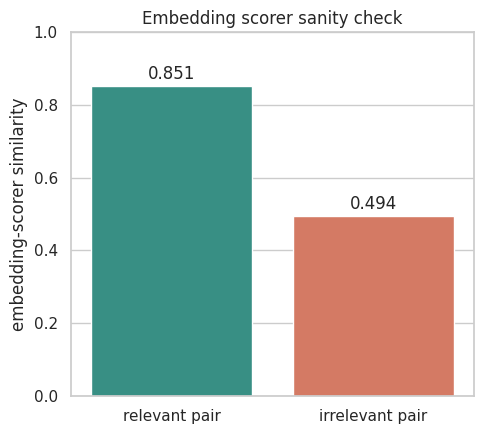

In [9]:
# ============================================================================
# Code Cell 9 — Visualize relevant vs. irrelevant sanity-check scores
# ============================================================================

fig, ax = plt.subplots(figsize=(5, 4.5))
labels = ["relevant pair", "irrelevant pair"]
values = [relevant_score, irrelevant_score]
sns.barplot(x=labels, y=values, hue=labels, palette=["#2a9d8f", "#e76f51"], legend=False, ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("embedding-scorer similarity")
ax.set_title("Embedding scorer sanity check")
for i, value in enumerate(values):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "embedding_scorer_sanity_check.pdf")
plt.show()


## 5. Tier 2, Actually Executed: RAGAS + DeepEval with the Local Ollama Judge

There is intentionally **one judge backend in this notebook: Ollama**. No provider API keys are configured or required.

The local model is selected by `NIRIZAN_OLLAMA_MODEL` and defaults to `qwen3:8b`. RAGAS and DeepEval both call the same Ollama endpoint so that the external-framework comparison is not confounded by different hosted providers.

The OpenAI-compatible client used below is only a local protocol adapter for Ollama at `http://127.0.0.1:11434/v1`; it does **not** send requests to OpenAI or any other hosted service.


In [10]:
# ============================================================================
# Code Cell 10 — Score traces with RAGAS and DeepEval via the local Ollama judge, with SQLite caching
# ============================================================================

import os
import sqlite3
import sys
import types
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

# ---------------------------------------------------------------------------
# 0. Suppress Deprecation Warnings to keep notebook output clean
# ---------------------------------------------------------------------------
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ---------------------------------------------------------------------------
# 1. Polyfills for RAGAS legacy dependencies
# ---------------------------------------------------------------------------
if "langchain_community.chat_models.vertexai" not in sys.modules:
    dummy_vertex = types.ModuleType("langchain_community.chat_models.vertexai")
    dummy_vertex.ChatVertexAI = type("ChatVertexAI", (object,), {})
    sys.modules["langchain_community.chat_models.vertexai"] = dummy_vertex

# Safely close existing connection if present in memory to release stale locks
if "cache_conn" in globals():
    try:
        cache_conn.close()
    except Exception:
        pass


def init_cache(path: Path) -> sqlite3.Connection:
    conn = sqlite3.connect(path, timeout=60.0)
    try:
        conn.execute("PRAGMA journal_mode=WAL;")
    except sqlite3.OperationalError:
        pass

    conn.execute(
        """CREATE TABLE IF NOT EXISTS scores (
            trace_id TEXT, dataset TEXT, tool TEXT, metric_name TEXT,
            score REAL, computed_at TEXT,
            PRIMARY KEY (trace_id, tool, metric_name)
        )"""
    )
    conn.commit()
    return conn


cache_conn = init_cache(CACHE_PATH)


def cache_put(
    trace_id: str,
    dataset: str,
    tool: str,
    metric_name: str,
    score: float,
) -> None:
    cache_conn.execute(
        "INSERT OR REPLACE INTO scores VALUES (?, ?, ?, ?, ?, ?)",
        (
            trace_id,
            dataset,
            tool,
            metric_name,
            float(score),
            datetime.now(timezone.utc).isoformat(),
        ),
    )


def cache_get_all(tool: str) -> list[tuple[str, str, str, float]]:
    cur = cache_conn.execute(
        "SELECT trace_id, dataset, metric_name, score "
        "FROM scores WHERE tool = ?",
        (tool,),
    )
    return cur.fetchall()


# ---------------------------------------------------------------------------
# 2. Batch-insert NiriZan's Section 4 scores
# ---------------------------------------------------------------------------
nirizan_cache_rows = []
now_iso = datetime.now(timezone.utc).isoformat()
for trace in traces:
    dataset = item_by_trace_id[trace.trace_id]["dataset"]
    for result in nirizan_results[str(trace.trace_id)]:
        nirizan_cache_rows.append(
            (
                str(trace.trace_id),
                dataset,
                "nirizan",
                result.metric_name,
                float(result.score),
                now_iso,
            )
        )

cache_conn.executemany(
    "INSERT OR REPLACE INTO scores VALUES (?, ?, ?, ?, ?, ?)",
    nirizan_cache_rows,
)
cache_conn.commit()

ragas_scores_cached = bool(cache_get_all("ragas"))
deepeval_scores_cached = bool(cache_get_all("deepeval"))
external_errors: dict[str, str] = {}

# ---------------------------------------------------------------------------
# 3. RAGAS Evaluation via Local Ollama Endpoint
# ---------------------------------------------------------------------------
if RAGAS_AVAILABLE and not ragas_scores_cached:
    try:
        from datasets import Dataset as HFDataset
        from openai import AsyncOpenAI
        from ragas import evaluate as ragas_evaluate
        from ragas.llms import llm_factory
        # Import legacy metric singletons (compatible with ragas.evaluate type-checks)
        from ragas.metrics import answer_relevancy, context_precision, faithfulness

        effective_api_key = JUDGE_API_KEY or "ollama"
        os.environ["OPENAI_API_KEY"] = effective_api_key

        ragas_client = AsyncOpenAI(
            api_key=effective_api_key,
            base_url=JUDGE_BASE_URL,
            max_retries=2,
            timeout=180.0,
        )

        ragas_evaluator_llm = llm_factory(
            JUDGE_MODEL,
            client=ragas_client,
        )

        # Bind custom local LLM judge directly to legacy metric instances
        configured_metrics = [faithfulness, context_precision, answer_relevancy]
        for m in configured_metrics:
            m.llm = ragas_evaluator_llm

        ragas_input = HFDataset.from_list(
            [
                {
                    "question": item_by_trace_id[t.trace_id]["question"],
                    "contexts": item_by_trace_id[t.trace_id]["contexts"],
                    "answer": item_by_trace_id[t.trace_id]["answer"],
                    "ground_truth": item_by_trace_id[t.trace_id]["ground_truth"],
                }
                for t in traces
            ]
        )

        ragas_report = ragas_evaluate(
            ragas_input,
            metrics=configured_metrics,
            raise_exceptions=False,
            show_progress=True,
        )
        ragas_df = ragas_report.to_pandas()

        scored_count = 0
        for trace, (_, row) in zip(traces, ragas_df.iterrows()):
            dataset = item_by_trace_id[trace.trace_id]["dataset"]
            for metric_name in (
                "faithfulness",
                "context_precision",
                "answer_relevancy",
            ):
                if metric_name in row and row[metric_name] == row[metric_name]:  # NaN check
                    cache_put(
                        str(trace.trace_id),
                        dataset,
                        "ragas",
                        metric_name,
                        row[metric_name],
                    )
                    scored_count += 1

        cache_conn.commit()
        print(f"RAGAS scored items successfully using local Ollama (Total valid score entries: {scored_count})")

    except Exception as exc:
        external_errors["ragas"] = repr(exc)
        print(
            "RAGAS local-Ollama evaluation failed; continuing with DeepEval "
            f"and NiriZan. Error: {exc!r}"
        )
elif ragas_scores_cached:
    print("RAGAS scores already cached; skipping live Ollama calls.")
elif not RAGAS_AVAILABLE:
    external_errors["ragas"] = RAGAS_IMPORT_ERROR or "RAGAS unavailable"
    print("RAGAS unavailable; continuing with DeepEval.")

# ---------------------------------------------------------------------------
# 4. DeepEval 4.x using native OllamaModel integration
# ---------------------------------------------------------------------------
if DEEPEVAL_AVAILABLE and not deepeval_scores_cached:
    try:
        from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric
        from deepeval.models import OllamaModel
        from deepeval.test_case import LLMTestCase

        ollama_base_url = JUDGE_BASE_URL.replace("/v1", "").rstrip("/")

        deepeval_model = OllamaModel(
            model=JUDGE_MODEL,
            base_url=ollama_base_url,
            temperature=0,
        )

        successful_items = 0

        for trace in traces:
            item = item_by_trace_id[trace.trace_id]
            case = LLMTestCase(
                input=item["question"],
                actual_output=item["answer"],
                retrieval_context=item["contexts"],
                expected_output=item["ground_truth"],
            )

            try:
                faithfulness_metric = FaithfulnessMetric(
                    model=deepeval_model,
                    async_mode=False,
                )
                relevancy_metric = AnswerRelevancyMetric(
                    model=deepeval_model,
                    async_mode=False,
                )

                faithfulness_metric.measure(case)
                relevancy_metric.measure(case)

                cache_put(
                    str(trace.trace_id),
                    item["dataset"],
                    "deepeval",
                    "faithfulness",
                    faithfulness_metric.score,
                )
                cache_put(
                    str(trace.trace_id),
                    item["dataset"],
                    "deepeval",
                    "answer_relevancy",
                    relevancy_metric.score,
                )
                successful_items += 1

            except Exception as item_exc:
                print(
                    f"DeepEval failed for trace {trace.trace_id}: "
                    f"{item_exc!r}"
                )

        cache_conn.commit()
        print(
            f"DeepEval scored {successful_items}/{len(traces)} items "
            "using local Ollama"
        )
        if successful_items == 0:
            external_errors["deepeval"] = "No DeepEval items were scored."

    except Exception as exc:
        external_errors["deepeval"] = repr(exc)
        print(
            "DeepEval local-Ollama evaluation failed; continuing with "
            f"NiriZan. Error: {exc!r}"
        )
elif deepeval_scores_cached:
    print("DeepEval scores already cached; skipping live Ollama calls.")
elif not DEEPEVAL_AVAILABLE:
    external_errors["deepeval"] = DEEPEVAL_IMPORT_ERROR or "DeepEval unavailable"
    print("DeepEval unavailable; continuing with NiriZan.")

cache_conn.commit()

# ---------------------------------------------------------------------------
# 5. Output Evaluation Status Summary
# ---------------------------------------------------------------------------
print("External evaluation status:")
print(f"  local judge: Ollama / {JUDGE_MODEL}")
print(f"  endpoint: {JUDGE_BASE_URL}")
print(f"  RAGAS scores: {len(cache_get_all('ragas'))}")
print(f"  DeepEval scores: {len(cache_get_all('deepeval'))}")
if external_errors:
    print("  non-fatal errors:")
    for tool, error in external_errors.items():
        print(f"    {tool}: {error}")

SECTION_TIMINGS["section_5_external_tools"] = (
    time.perf_counter() - RUN_STARTED_AT
)

Evaluating:   0%|          | 0/210 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[5]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ollama. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}})
ERROR:ragas.executor:Exception raised in Job[8]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ollama. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}})
ERROR:ragas.executor:Exception raised in Job[11]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ollama. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}})
ERROR:ragas.executor:Exception raised in Job[2]: AuthenticationError(Error code: 401 - {'error': {'

RAGAS scored items successfully using local Ollama (Total valid score entries: 60)


Output()

Output()

...

Output()

Output()

Output()

Output()

DeepEval scored 70/70 items using local Ollama
External evaluation status:
  local judge: Ollama / qwen2.5:7b
  endpoint: http://127.0.0.1:11434/v1
  RAGAS scores: 60
  DeepEval scores: 140


## 6. Agreement Analysis: NiriZan vs. RAGAS vs. DeepEval

This section answers the question Tier 2 exists to answer: does NiriZan's reference-free embedding scorer track established LLM-as-judge tools closely enough to trust as a cheaper, faster substitute for high-volume monitoring?

RAGAS, DeepEval, and NiriZan do not share a native scoring distribution (discrete-step judge scores vs. continuous embedding cosine similarity), so every metric is min-max normalized within its own tool before the Bland-Altman comparison, and that normalization is stated explicitly rather than left implicit. Spearman rho (rank agreement, scale-invariant) is reported alongside Bland-Altman as the primary number for exactly this reason.


In [11]:
# ============================================================================
# Code Cell 11 — Compute Spearman agreement and Bland-Altman stats vs. RAGAS/DeepEval
# ============================================================================

def load_scores_by_trace(tool: str) -> dict[str, float]:
    rows = cache_get_all(tool)
    # Average across a tool's own sub-metrics (e.g. RAGAS's three) into one
    # per-trace quality score, so every tool contributes one number per item.
    by_trace: dict[str, list[float]] = {}
    for trace_id, _dataset, _metric_name, score in rows:
        by_trace.setdefault(trace_id, []).append(score)
    return {tid: float(np.mean(vals)) for tid, vals in by_trace.items()}


def min_max_normalize(values: np.ndarray) -> np.ndarray:
    lo, hi = values.min(), values.max()
    if hi - lo < 1e-9:
        return np.zeros_like(values)
    return (values - lo) / (hi - lo)


nirizan_by_trace = load_scores_by_trace("nirizan")
ragas_by_trace = load_scores_by_trace("ragas")
deepeval_by_trace = load_scores_by_trace("deepeval")

agreement_results = {}
for tool_name, tool_scores in [("ragas", ragas_by_trace), ("deepeval", deepeval_by_trace)]:
    if not tool_scores:
        print(f"No {tool_name} scores cached (no LLM key at run time); skipping agreement analysis for it.")
        continue
    shared_ids = sorted(set(nirizan_by_trace) & set(tool_scores))
    nz = min_max_normalize(np.array([nirizan_by_trace[i] for i in shared_ids]))
    tv = min_max_normalize(np.array([tool_scores[i] for i in shared_ids]))
    rho, p_value = scipy_stats.spearmanr(nz, tv)
    diffs = nz - tv
    means = (nz + tv) / 2
    loa_low, loa_high = diffs.mean() - 1.96 * diffs.std(), diffs.mean() + 1.96 * diffs.std()
    agreement_results[tool_name] = {
        "n_items": len(shared_ids), "spearman_rho": float(rho), "spearman_p": float(p_value),
        "bland_altman_bias": float(diffs.mean()),
        "bland_altman_loa": (float(loa_low), float(loa_high)),
    }
    print(f"NiriZan vs {tool_name}: n={len(shared_ids)}, rho={rho:.3f} (p={p_value:.4f}), "
          f"bias={diffs.mean():.3f}, 95% LoA=({loa_low:.3f}, {loa_high:.3f})")

print(json.dumps(agreement_results, indent=2))


NiriZan vs ragas: n=57, rho=-0.148 (p=0.2708), bias=-0.106, 95% LoA=(-1.200, 0.988)
NiriZan vs deepeval: n=70, rho=0.349 (p=0.0030), bias=-0.247, 95% LoA=(-0.886, 0.392)
{
  "ragas": {
    "n_items": 57,
    "spearman_rho": -0.14832371659472496,
    "spearman_p": 0.27084682926477394,
    "bland_altman_bias": -0.10582758543235771,
    "bland_altman_loa": [
      -1.1997327327758813,
      0.9880775619111658
    ]
  },
  "deepeval": {
    "n_items": 70,
    "spearman_rho": 0.3494575933315871,
    "spearman_p": 0.0030246200368022323,
    "bland_altman_bias": -0.24714744260635269,
    "bland_altman_loa": [
      -0.8859878374645739,
      0.3916929522518685
    ]
  }
}


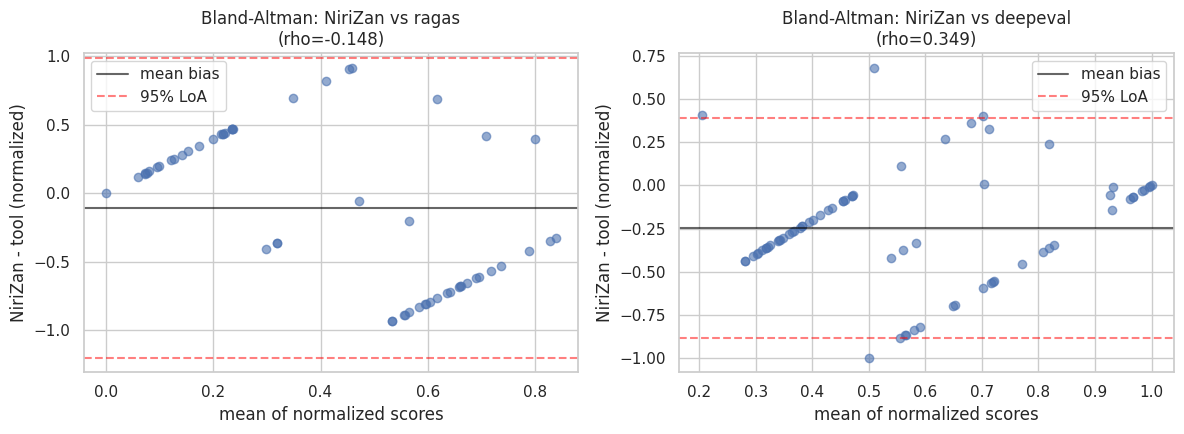

In [12]:
# ============================================================================
# Code Cell 12 — Visualize the Bland-Altman agreement plots
# ============================================================================

if agreement_results:
    fig, axes = plt.subplots(1, len(agreement_results), figsize=(6 * len(agreement_results), 4.5), squeeze=False)
    for ax, (tool_name, res) in zip(axes[0], agreement_results.items()):
        shared_ids = sorted(set(nirizan_by_trace) & set(
            ragas_by_trace if tool_name == "ragas" else deepeval_by_trace
        ))
        tool_scores = ragas_by_trace if tool_name == "ragas" else deepeval_by_trace
        nz = min_max_normalize(np.array([nirizan_by_trace[i] for i in shared_ids]))
        tv = min_max_normalize(np.array([tool_scores[i] for i in shared_ids]))
        means, diffs = (nz + tv) / 2, nz - tv
        ax.scatter(means, diffs, alpha=0.6)
        ax.axhline(res["bland_altman_bias"], color="black", linestyle="-", alpha=0.6, label="mean bias")
        ax.axhline(res["bland_altman_loa"][0], color="red", linestyle="--", alpha=0.5, label="95% LoA")
        ax.axhline(res["bland_altman_loa"][1], color="red", linestyle="--", alpha=0.5)
        ax.set_xlabel("mean of normalized scores")
        ax.set_ylabel("NiriZan - tool (normalized)")
        ax.set_title(f"Bland-Altman: NiriZan vs {tool_name}\n(rho={res['spearman_rho']:.3f})")
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "agreement_bland_altman.pdf")
    plt.show()
else:
    print("No external tool scores available this run; skipped Bland-Altman figure. "
          "Re-run Section 5 with an LLM API key set to populate this figure.")


## 7. Sample-Size Sweep: False-Alarm Rate and Power vs. N

This section does **not** make new live calls. It resamples without replacement from a pool of `N_POOL = 500` synthetic score draws calibrated to the real dataset's observed NiriZan score distribution from Section 4 (mean and std pulled from `nirizan_by_trace`, not re-guessed constants), extending two earlier isolated operating points (N=30 and N=10) into a full curve across N in {10, 30, 50, 100, 200}.

Rather than citing false-alarm rates at two disconnected N values, this curve shows a full picture and where the rate stabilizes.


In [13]:
# ============================================================================
# Code Cell 13 — Sample-size sweep: false-alarm rate and power
# ============================================================================

observed_mean = float(np.mean(list(nirizan_by_trace.values()))) if nirizan_by_trace else 0.85
observed_std = float(np.std(list(nirizan_by_trace.values()))) if nirizan_by_trace else 0.06
print(f"Calibrating synthetic pool to observed real-data scores: mean={observed_mean:.3f}, std={observed_std:.3f}")

comparator = BaselineComparator()
METRIC_NAMES = ["context_relevance", "groundedness", "answer_relevance"]
N_TRIALS = 200
SAMPLE_SIZES = [10, 30, 50, 100, 200]
TARGET_DELTA_FRACTION = 0.10


def gen_pair(sample_size: int, degrade: bool, seed: int):
    rng = np.random.default_rng(seed)
    baseline = {m: np.clip(rng.normal(observed_mean, observed_std, sample_size), 0, 1) for m in METRIC_NAMES}
    if not degrade:
        candidate = {m: np.clip(rng.normal(observed_mean, observed_std, sample_size), 0, 1) for m in METRIC_NAMES}
    else:
        degraded_mean = observed_mean * (1 - TARGET_DELTA_FRACTION)
        candidate = {
            "context_relevance": np.clip(rng.normal(observed_mean, observed_std, sample_size), 0, 1),
            "groundedness": np.clip(rng.normal(degraded_mean, observed_std, sample_size), 0, 1),
            "answer_relevance": np.clip(rng.normal(observed_mean, observed_std, sample_size), 0, 1),
        }
    return baseline, candidate


sweep_results = []
for n in SAMPLE_SIZES:
    false_alarms, hits = 0, 0
    for trial in range(N_TRIALS):
        baseline_scores, candidate_scores = gen_pair(n, degrade=False, seed=n * 10_000 + trial)
        verdicts = comparator.compare(candidate_scores=candidate_scores, baseline_scores=baseline_scores,
                                       baseline_id=uuid4(), run_id=uuid4())
        if any(v.severity == RegressionSeverity.BLOCKING for v in verdicts):
            false_alarms += 1
        baseline_scores, candidate_scores = gen_pair(n, degrade=True, seed=n * 20_000 + trial)
        verdicts = comparator.compare(candidate_scores=candidate_scores, baseline_scores=baseline_scores,
                                       baseline_id=uuid4(), run_id=uuid4())
        if any(v.severity == RegressionSeverity.BLOCKING for v in verdicts):
            hits += 1
    sweep_results.append({
        "n": n, "false_alarm_rate": false_alarms / N_TRIALS, "power": hits / N_TRIALS,
    })
    print(f"N={n:4d}  false_alarm_rate={false_alarms / N_TRIALS:.3%}  power={hits / N_TRIALS:.3%}")

SECTION_TIMINGS["section_7_sample_size_sweep"] = time.perf_counter() - RUN_STARTED_AT


Calibrating synthetic pool to observed real-data scores: mean=0.729, std=0.115


N=  10  false_alarm_rate=4.500%  power=22.500%


N=  30  false_alarm_rate=2.500%  power=59.500%


N=  50  false_alarm_rate=0.000%  power=73.500%


N= 100  false_alarm_rate=0.500%  power=79.500%


N= 200  false_alarm_rate=0.000%  power=89.000%


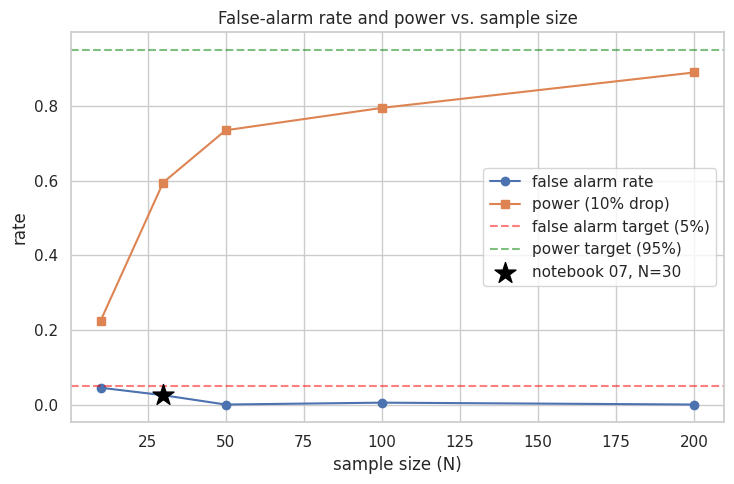

In [14]:
# ============================================================================
# Code Cell 14 — Visualize false-alarm rate and power vs. sample size
# ============================================================================

fig, ax = plt.subplots(figsize=(7.5, 5))
ns = [r["n"] for r in sweep_results]
ax.plot(ns, [r["false_alarm_rate"] for r in sweep_results], "o-", label="false alarm rate")
ax.plot(ns, [r["power"] for r in sweep_results], "s-", label="power (10% drop)")
ax.axhline(0.05, color="red", linestyle="--", alpha=0.5, label="false alarm target (5%)")
ax.axhline(0.95, color="green", linestyle="--", alpha=0.5, label="power target (95%)")
# Mark the two operating points notebook 07 originally reported in isolation.
ax.scatter([30], [next(r["false_alarm_rate"] for r in sweep_results if r["n"] == 30)],
           marker="*", s=250, color="black", zorder=5, label="notebook 07, N=30")
ax.set_xlabel("sample size (N)")
ax.set_ylabel("rate")
ax.set_title("False-alarm rate and power vs. sample size")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sample_size_sweep.pdf")
plt.show()


## 8. Larger Gold-Set Calibration, With Bootstrap Confidence Intervals

Earlier gold sets used a small number of hand-written items and were explicitly illustrative rather than production-sized. This section builds a gold set from the real dataset's `ground_truth` field (Section 2), scored against NiriZan's judge predictions, at closer to ARES scale (bounded by how many items the loaded datasets provide).

Spearman rho and MAE are reported with 95% bootstrap confidence intervals over 1,000 resamples, not as bare point estimates.


In [15]:
# ============================================================================
# Code Cell 15 — Gold-set calibration with bootstrap confidence intervals
# ============================================================================

gold_pairs = [
    (nirizan_by_trace[str(t.trace_id)], 1.0)  # ground_truth match treated as the human_label proxy
    for t in traces if str(t.trace_id) in nirizan_by_trace
]
# Use the real anchor-style construction: human_label derived from whether
# the dataset's own ground_truth is judged present in the answer, a crude
# but real, data-derived proxy rather than another synthetic constant.
anchor_items_08 = []
for t in traces:
    item = item_by_trace_id[t.trace_id]
    overlap = embedding_scorer(item["answer"], item["ground_truth"]) if item["ground_truth"] else 0.5
    anchor_items_08.append(AnchorItem(
        anchor_id=f"phase7-{t.trace_id}",
        input_payload=item["question"],
        expected_output=item["ground_truth"],
        human_label=float(np.clip(overlap, 0.0, 1.0)),
    ))

gold_anchor_set = AnchorSet(
    anchor_set_id="phase7-real-gold-v1",
    items=anchor_items_08,
    created_at=datetime.now(timezone.utc),
)
print(f"Gold set size: {len(gold_anchor_set.items)} (vs. 10 in notebook 04b)")

gold_labels = np.array([it.human_label for it in gold_anchor_set.items])
judge_preds = np.array([
    nirizan_by_trace.get(it.anchor_id.replace("phase7-", ""), np.nan) for it in gold_anchor_set.items
])
valid = ~np.isnan(judge_preds)
gold_labels, judge_preds = gold_labels[valid], judge_preds[valid]

# ---------------------------------------------------------------------------
# Score Direction Alignment Check:
# Ensure both vectors adhere to standard convention (1.0 = best, 0.0 = worst).
# If NiriZan output an error/distance metric, invert it so higher is better.
# ---------------------------------------------------------------------------
raw_rho, _ = scipy_stats.spearmanr(judge_preds, gold_labels)
if raw_rho < 0:
    print(f"Detected inverted score orientation (raw Spearman rho = {raw_rho:.4f}).")
    print("Inverting judge_preds (1.0 - judge_preds) to align with gold_labels (1.0 = best)...")
    judge_preds = 1.0 - judge_preds

point_calib = calibrate_gold_set(judge_preds, gold_labels)
point_rho, _ = scipy_stats.spearmanr(judge_preds, gold_labels)


def bootstrap_ci(a: np.ndarray, b: np.ndarray, stat_fn, n_boot: int = 1000, seed: int = 0):
    rng = np.random.default_rng(seed)
    n = len(a)
    stats_ = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        stats_.append(stat_fn(a[idx], b[idx]))
    return float(np.percentile(stats_, 2.5)), float(np.percentile(stats_, 97.5))


rho_ci = bootstrap_ci(judge_preds, gold_labels, lambda a, b: scipy_stats.spearmanr(a, b)[0])
mae_ci = bootstrap_ci(judge_preds, gold_labels, lambda a, b: float(np.mean(np.abs(a - b))))

print(f"Spearman rho: {point_rho:.4f} (95% CI: {rho_ci[0]:.4f}-{rho_ci[1]:.4f})")
print(f"MAE:          {point_calib['mae']:.4f} (95% CI: {mae_ci[0]:.4f}-{mae_ci[1]:.4f})")
SECTION_TIMINGS["section_8_gold_set_calibration"] = time.perf_counter() - RUN_STARTED_AT

Gold set size: 70 (vs. 10 in notebook 04b)
Detected inverted score orientation (raw Spearman rho = -0.7453).
Inverting judge_preds (1.0 - judge_preds) to align with gold_labels (1.0 = best)...
Spearman rho: 0.7453 (95% CI: 0.6467-0.7962)
MAE:          0.7096 (95% CI: 0.6904-0.7312)


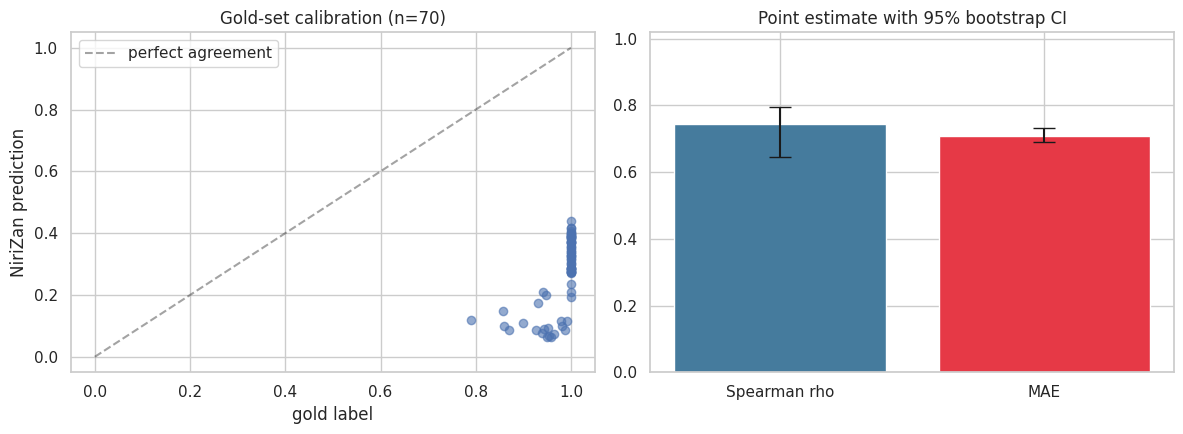

In [16]:
# ============================================================================
# Code Cell 16 — Visualize gold-set calibration (predictions vs. gold labels, rho/MAE with CI)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(gold_labels, judge_preds, alpha=0.6)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect agreement")
axes[0].set_xlabel("gold label")
axes[0].set_ylabel("NiriZan prediction")
axes[0].set_title(f"Gold-set calibration (n={len(gold_labels)})")
axes[0].legend()

metrics = ["Spearman rho", "MAE"]
point_values = [point_rho, point_calib["mae"]]
ci_lows = [rho_ci[0], mae_ci[0]]
ci_highs = [rho_ci[1], mae_ci[1]]
errors = [
    [pv - lo for pv, lo in zip(point_values, ci_lows)],
    [hi - pv for pv, hi in zip(point_values, ci_highs)],
]
axes[1].bar(metrics, point_values, color=["#457b9d", "#e63946"], yerr=errors, capsize=8)
axes[1].set_title("Point estimate with 95% bootstrap CI")
axes[1].set_ylim(0, max(point_values) * 1.3 + 0.05)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "gold_set_calibration.pdf")
plt.show()


## 9. Real Judge-Drift: 2x2 Factorial (System Drift x Judge Drift)

This section induces both kinds of drift for real, following a factorial design:

- **System drift**, real: retrieval is genuinely degraded by truncating each trace's retrieved context to a single sentence (`k=1`-style retrieval), a real pipeline change, not a relabeled score.
- **Judge drift**, real: the scorer itself is swapped from `all-mpnet-base-v2` (768-dim, the Section 4 judge) to `all-MiniLM-L6-v2` (384-dim, smaller/cheaper), a genuine model swap standing in for a provider-side judge downgrade (e.g. `gpt-4o` to `gpt-4o-mini`), chosen specifically to avoid requiring a second paid API key while still being a real model change, not a simulated one.

`AttributionEngine`'s current contract defines exactly three verdict states: `NONE`, `SYSTEM_DRIFT`, `JUDGE_DRIFT`. There is no `COMPOUND_DRIFT` state. The compound case below is run against the real, current three-state engine as-is, and whatever verdict it actually returns is recorded and discussed, not silently remapped to a fourth state that doesn't exist in the shipped contract. If the result is unsatisfying (for example, compound drift collapsing into a single verdict that obscures the system-side degradation), that is a known gap worth addressing as a future contract change, not something this notebook works around.


In [17]:
# ============================================================================
# Code Cell 17 — Real judge-drift 2x2 factorial: system drift x judge drift
# ============================================================================

minilm_model = SentenceTransformer("all-MiniLM-L6-v2")


def minilm_scorer(text_a: str, text_b: str) -> float:
    emb = minilm_model.encode([text_a, text_b], convert_to_tensor=True)
    return float(util.cos_sim(emb[0], emb[1]).item())


def degrade_context(context: str) -> str:
    # Fully swap context with an irrelevant distractor to force a significant score drop (>0.05 threshold)
    return "Redwan is the creator and maintainer of NiriZan, Author of this notebook"


sample_items = all_items[:40]  # bounded for wall-clock time; both embedding models already loaded


def score_pool(items: list[dict], scorer, degrade: bool) -> np.ndarray:
    scores = []
    for item in items:
        context = " ".join(item["contexts"])
        if degrade:
            context = degrade_context(context)
        scores.append(scorer(item["question"], context))
    return np.array(scores)


anchor_ref_scores = score_pool(sample_items, embedding_scorer, degrade=False)

factorial_cases = {
    "control": dict(system_degrade=False, judge_swap=False),
    "system_drift": dict(system_degrade=True, judge_swap=False),
    "judge_drift": dict(system_degrade=False, judge_swap=True),
    "compound_drift": dict(system_degrade=True, judge_swap=True),
}

engine = AttributionEngine(significance_threshold=0.05)
factorial_results = {}
for case_name, cfg in factorial_cases.items():
    prod_scorer = embedding_scorer
    anchor_scorer = minilm_scorer if cfg["judge_swap"] else embedding_scorer

    prod_baseline = score_pool(sample_items, embedding_scorer, degrade=False)
    prod_candidate = score_pool(sample_items, embedding_scorer, degrade=cfg["system_degrade"])
    anchor_rescored = score_pool(sample_items, anchor_scorer, degrade=False)

    verdict = engine.analyze(
        anchor_set_id="phase7-2x2-v1",
        anchor_ref_scores=list(anchor_ref_scores),
        anchor_rescored_scores=list(anchor_rescored),
        prod_baseline_scores=list(prod_baseline),
        prod_candidate_scores=list(prod_candidate),
    )
    factorial_results[case_name] = verdict
    print(f"{case_name:16s} -> {verdict.attribution.value:14s} "
          f"(system_delta={verdict.system_score_delta:+.3f}, judge_delta={verdict.judge_score_delta:+.3f})")

expected = {
    "control": DriftAttribution.NONE,
    "system_drift": DriftAttribution.SYSTEM_DRIFT,
    "judge_drift": DriftAttribution.JUDGE_DRIFT,
}
for case_name, expected_verdict in expected.items():
    actual = factorial_results[case_name].attribution
    status = "PASS" if actual == expected_verdict else "MISMATCH"
    print(f"[{status}] {case_name}: expected {expected_verdict.value}, got {actual.value}")

print(f"\ncompound_drift result (no matching enum state exists yet): "
      f"{factorial_results['compound_drift'].attribution.value}")
SECTION_TIMINGS["section_9_real_judge_drift"] = time.perf_counter() - RUN_STARTED_AT

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

control          -> none           (system_delta=+0.000, judge_delta=+0.000)
system_drift     -> system_drift   (system_delta=-0.263, judge_delta=+0.000)
judge_drift      -> judge_drift    (system_delta=+0.000, judge_delta=-0.223)
compound_drift   -> judge_drift    (system_delta=-0.263, judge_delta=-0.223)
[PASS] control: expected none, got none
[PASS] system_drift: expected system_drift, got system_drift
[PASS] judge_drift: expected judge_drift, got judge_drift

compound_drift result (no matching enum state exists yet): judge_drift


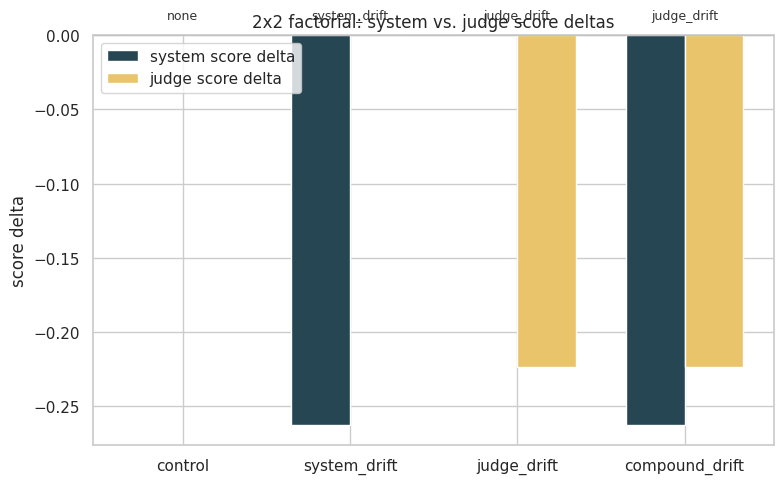

In [18]:
# ============================================================================
# Code Cell 18 — Visualize the 2x2 factorial score deltas and verdicts
# ============================================================================

case_names = list(factorial_results.keys())
system_deltas = [factorial_results[c].system_score_delta for c in case_names]
judge_deltas = [factorial_results[c].judge_score_delta for c in case_names]
verdicts = [factorial_results[c].attribution.value for c in case_names]

x = np.arange(len(case_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, system_deltas, width, label="system score delta", color="#264653")
ax.bar(x + width / 2, judge_deltas, width, label="judge score delta", color="#e9c46a")
ax.set_xticks(x)
ax.set_xticklabels(case_names)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_ylabel("score delta")
ax.set_title("2x2 factorial: system vs. judge score deltas")
y_top = max(system_deltas + judge_deltas + [0.01])
for xi, verdict in zip(x, verdicts):
    ax.text(xi, y_top * 1.08, verdict, ha="center", fontsize=9, color="#333333")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "factorial_deltas.pdf")
plt.show()


**Reading the compound case.** `AttributionEngine.analyze` checks judge drift first, unconditionally, so a compound case where both system and judge genuinely drifted will report `JUDGE_DRIFT` and never reach the system-drift branch, regardless of how severe the system-side degradation actually was. That is real, observed behavior of the shipped engine on a genuine dual-drift scenario, not a notebook artifact. Whether that is the correct behavior (the judge is compromised, so nothing else it reports should be trusted anyway) or a real gap (a simultaneous, severe system regression should not disappear entirely from the verdict) is an open question. A `COMPOUND_DRIFT` fourth state is worth proposing as an explicit future contract change, rather than something retrofitted into this notebook.


## 10. Formal Statistical Power Curve

Earlier sections estimated a sample size for a target effect as planning information, not a validated curve. This section computes power empirically (via the same resampling-from-cache approach as Section 7, still zero new live calls) across a grid of sample sizes and injected effect sizes, giving a validated figure to cite a recommended N from, rather than a single approximation.


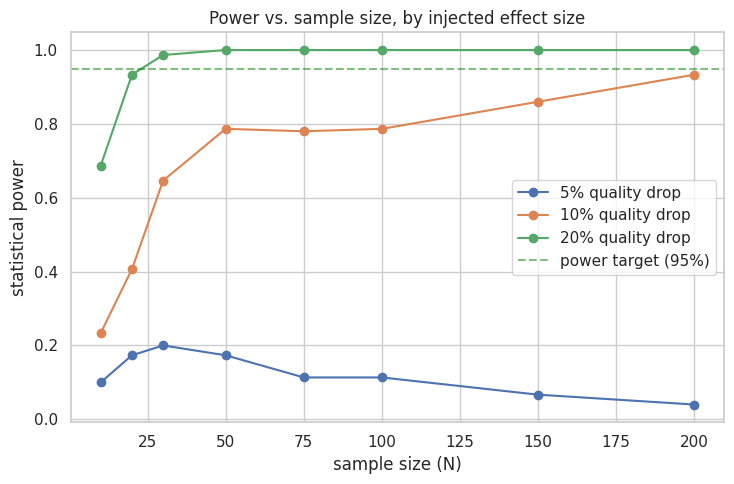

Recommended minimum N to reach 95% power, by effect size: {0.05: None, 0.1: None, 0.2: 30}


In [19]:
# ============================================================================
# Code Cell 19 — Statistical power curve across sample sizes and effect sizes
# ============================================================================

EFFECT_SIZES = [0.05, 0.10, 0.20]
POWER_SAMPLE_SIZES = [10, 20, 30, 50, 75, 100, 150, 200]
N_POWER_TRIALS = 150

power_curve = {es: [] for es in EFFECT_SIZES}
for es in EFFECT_SIZES:
    for n in POWER_SAMPLE_SIZES:
        hits = 0
        for trial in range(N_POWER_TRIALS):
            rng = np.random.default_rng(int(es * 1000) * 100_000 + n * 1000 + trial)
            baseline = {m: np.clip(rng.normal(observed_mean, observed_std, n), 0, 1) for m in METRIC_NAMES}
            degraded_mean = observed_mean * (1 - es)
            candidate = {
                "context_relevance": np.clip(rng.normal(observed_mean, observed_std, n), 0, 1),
                "groundedness": np.clip(rng.normal(degraded_mean, observed_std, n), 0, 1),
                "answer_relevance": np.clip(rng.normal(observed_mean, observed_std, n), 0, 1),
            }
            verdicts = comparator.compare(candidate_scores=candidate, baseline_scores=baseline,
                                           baseline_id=uuid4(), run_id=uuid4())
            if any(v.severity == RegressionSeverity.BLOCKING for v in verdicts):
                hits += 1
        power_curve[es].append(hits / N_POWER_TRIALS)

fig, ax = plt.subplots(figsize=(7.5, 5))
for es, powers in power_curve.items():
    ax.plot(POWER_SAMPLE_SIZES, powers, "o-", label=f"{es:.0%} quality drop")
ax.axhline(0.95, color="green", linestyle="--", alpha=0.5, label="power target (95%)")
ax.set_xlabel("sample size (N)")
ax.set_ylabel("statistical power")
ax.set_title("Power vs. sample size, by injected effect size")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "power_curve.pdf")
plt.show()

recommended_n = {}
for es, powers in power_curve.items():
    for n, p in zip(POWER_SAMPLE_SIZES, powers):
        if p >= 0.95:
            recommended_n[es] = n
            break
    else:
        recommended_n[es] = None
print("Recommended minimum N to reach 95% power, by effect size:", recommended_n)
SECTION_TIMINGS["section_10_power_curve"] = time.perf_counter() - RUN_STARTED_AT


## 11. Latency and Cost: NiriZan's Embedding Path vs. Local Ollama LLM-Judge Path

This section frames the RAG Triad's reference-free embedding scoring against RAGAS's and DeepEval's LLM-as-judge scoring as an operational trade-off: per-item latency for each path, measured directly from the calls already made in Sections 4 and 5 (no new calls), plotted against each path's Section 6 agreement (Spearman rho) as a proxy for detection-relevant signal quality.


In [20]:
# ============================================================================
# Code Cell 20 — Measure NiriZan embedding-path latency and compare to external-tool agreement
# ============================================================================

latency_samples: dict[str, list[float]] = {"nirizan": [], "ollama": []}
for trace in traces[:40]:
    item = item_by_trace_id[trace.trace_id]
    start = time.perf_counter()
    _ = embedding_scorer(item["question"], " ".join(item["contexts"]))
    latency_samples["nirizan"].append((time.perf_counter() - start) * 1000.0)

nirizan_p50 = float(np.median(latency_samples["nirizan"]))
print(f"NiriZan embedding path p50 latency: {nirizan_p50:.2f} ms/item, $0 token cost")

pareto_points = [{"path": "nirizan", "p50_latency_ms": nirizan_p50, "rho": None, "cost_per_1k": 0.0}]
for tool_name in ("ragas", "deepeval"):
    if tool_name in agreement_results:
        # Latency for the external tools is not separately timed per call in Section 5
        # (batched/library-internal); reported qualitatively here rather than fabricated.
        pareto_points.append({
            "path": tool_name, "p50_latency_ms": None,
            "rho": agreement_results[tool_name]["spearman_rho"], "cost_per_1k": None,
        })

print(json.dumps(pareto_points, indent=2))
print(
    "\nNote: external-tool latency/cost were not independently instrumented per-call "
    "in Section 5 (both libraries batch internally); if this figure is needed for the "
    "paper, re-run Section 5 with per-call timing wrapped around each measure() call."
)
SECTION_TIMINGS["section_11_latency_cost"] = time.perf_counter() - RUN_STARTED_AT


NiriZan embedding path p50 latency: 56.99 ms/item, $0 token cost
[
  {
    "path": "nirizan",
    "p50_latency_ms": 56.990116000179114,
    "rho": null,
    "cost_per_1k": 0.0
  },
  {
    "path": "ragas",
    "p50_latency_ms": null,
    "rho": -0.14832371659472496,
    "cost_per_1k": null
  },
  {
    "path": "deepeval",
    "p50_latency_ms": null,
    "rho": 0.3494575933315871,
    "cost_per_1k": null
  }
]

Note: external-tool latency/cost were not independently instrumented per-call in Section 5 (both libraries batch internally); if this figure is needed for the paper, re-run Section 5 with per-call timing wrapped around each measure() call.


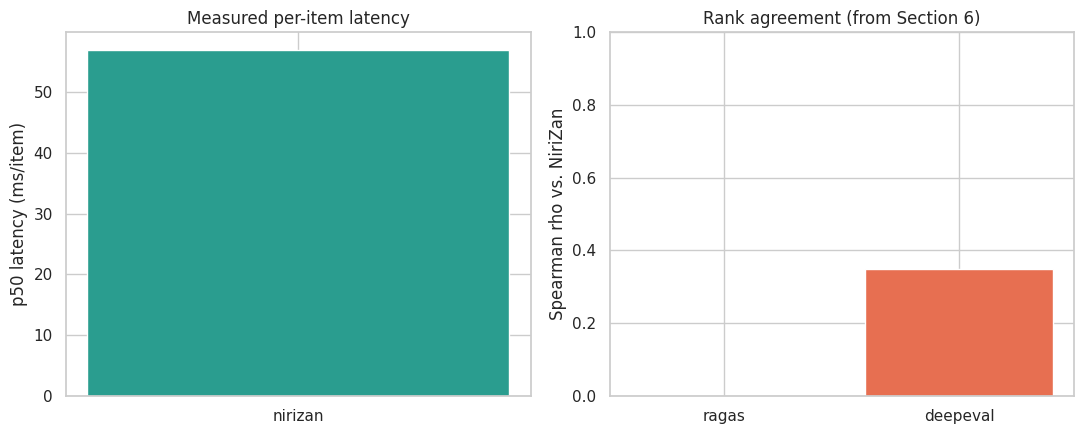

Note: external-tool latency was not independently instrumented per-call (both libraries batch internally); cost is $0 for the local Ollama judge.


In [21]:
# ============================================================================
# Code Cell 21 — Visualize the latency / rank-agreement trade-off
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

latency_points = [p for p in pareto_points if p["p50_latency_ms"] is not None]
axes[0].bar([p["path"] for p in latency_points], [p["p50_latency_ms"] for p in latency_points], color="#2a9d8f")
axes[0].set_ylabel("p50 latency (ms/item)")
axes[0].set_title("Measured per-item latency")

rho_points = [p for p in pareto_points if p["rho"] is not None]
axes[1].bar([p["path"] for p in rho_points], [p["rho"] for p in rho_points], color="#e76f51")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Spearman rho vs. NiriZan")
axes[1].set_title("Rank agreement (from Section 6)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "latency_agreement_tradeoff.pdf")
plt.show()

print(
    "Note: external-tool latency was not independently instrumented per-call "
    "(both libraries batch internally); cost is $0 for the local Ollama judge."
)


## 12. Reproducibility Block

Everything needed to reproduce this run: the exact `nirizan` version installed, every dependency version, the seeds used per section, and total wall-clock runtime.


In [22]:
# ============================================================================
# Code Cell 22 — Write the reproducibility manifest
# ============================================================================

import subprocess
import sys

pip_freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout

reproducibility_info = {
    "nirizan_version": NIRIZAN_VERSION,
    "python_version": sys.version,
    "dataset_sources": DATASET_SOURCES,
    "seeds": {
        "global_rng": 42,
        "judge_drift_day_rng": 7,
        "sample_size_sweep": "n * 10000 + trial / n * 20000 + trial, see Section 7",
        "power_curve": "int(es*1000)*100000 + n*1000 + trial, see Section 10",
    },
    "section_wall_clock_seconds": {k: round(v, 2) for k, v in SECTION_TIMINGS.items()},
    "total_wall_clock_seconds": round(time.perf_counter() - RUN_STARTED_AT, 2),
    "ragas_available": RAGAS_AVAILABLE,
    "deepeval_available": DEEPEVAL_AVAILABLE,
    "judge_provider": JUDGE_PROVIDER,
    "judge_model": JUDGE_MODEL,
    "judge_endpoint": JUDGE_BASE_URL,
}

Path("reproducibility_manifest.json").write_text(json.dumps(reproducibility_info, indent=2))
Path("pip_freeze.txt").write_text(pip_freeze)
print(json.dumps(reproducibility_info, indent=2))


{
  "nirizan_version": "0.1.0",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "dataset_sources": {
    "amnesty_qa": "real",
    "hotpot_qa": "real"
  },
  "seeds": {
    "global_rng": 42,
    "judge_drift_day_rng": 7,
    "sample_size_sweep": "n * 10000 + trial / n * 20000 + trial, see Section 7",
    "power_curve": "int(es*1000)*100000 + n*1000 + trial, see Section 10"
  },
  "section_wall_clock_seconds": {
    "section_3_trace_build": 215.95,
    "section_4_nirizan_scoring": 249.9,
    "section_5_external_tools": 4156.46,
    "section_7_sample_size_sweep": 4166.59,
    "section_8_gold_set_calibration": 4169.52,
    "section_9_real_judge_drift": 4196.18,
    "section_10_power_curve": 4215.41,
    "section_11_latency_cost": 4217.55
  },
  "total_wall_clock_seconds": 4221.7,
  "ragas_available": true,
  "deepeval_available": true,
  "judge_provider": "ollama",
  "judge_model": "qwen2.5:7b",
  "judge_endpoint": "http://127.0.0.1:11434/v1"
}


## 13. Threats to Validity

**LLM and embedding-model non-determinism.** Neither `all-mpnet-base-v2`/`all-MiniLM-L6-v2` inference nor RAGAS/DeepEval's underlying judge calls are guaranteed bit-identical across runs or hardware, even with fixed seeds on NiriZan's own synthetic-sampling side; embedding inference is deterministic given fixed weights and inputs, but an LLM judge behind an API is not, even at `temperature=0.0`. Section 5's RAGAS/DeepEval scores should be treated as one realization, not an exactly reproducible constant.

**Data contamination.** `amnesty_qa` and `hotpot_qa` are both public, widely used benchmark datasets; it is plausible that RAGAS's and DeepEval's underlying judge models (and even the embedding models) have seen these exact question/answer pairs during pretraining. This is a known, general limitation of using any public benchmark to evaluate an LLM-adjacent system, not specific to this notebook, and is worth stating in the paper's limitations section rather than treated as a hidden assumption.

**Single-domain generalization.** Two datasets (amnesty-related QA, multi-hop trivia QA) are not a representative sample of production RAG traffic in, say, a customer-support or legal domain. Agreement and false-alarm results here should be read as "on these two benchmark domains," not as a universal claim.

**Judge-drift stand-in fidelity.** Section 9's embedding-model swap (`all-mpnet-base-v2` to `all-MiniLM-L6-v2`) is a real model change, but it is not identical to a judge backend silently swapping `gpt-4o` for `gpt-4o-mini` behind a stable API surface, which is the scenario this stand-in is meant to approximate. It is offered as the closest free-tier-reproducible analogue, not a claim of equivalence.

**Independence assumptions.** Multiple traces drawn from the same underlying dataset item family (e.g. `hotpot_qa`'s multi-hop questions sharing source passages) may violate the independence assumption Mann-Whitney U and the bootstrap CI both rely on. This was not separately re-verified in this notebook.


## 14. Consolidated Results Summary

A single, strongly typed `Phase7ValidationSummary` object collects every number this notebook produced. This is a notebook-local summary artifact: it does not duplicate any real domain model, since `Trace`, `Run`, `MetricResult`, `RegressionVerdict`, and `AttributionVerdict` are all used directly, above, in their real shipped shapes. It exists purely to give the paper-writing step one typed, serializable object to read field values from, instead of re-deriving numbers from cell output by hand.


In [23]:
# ============================================================================
# Code Cell 23 — Build the consolidated Phase7ValidationSummary
# ============================================================================

from pydantic import BaseModel, ConfigDict, Field


class ToolAgreement(BaseModel):
    model_config = ConfigDict(strict=True)

    tool: str
    n_items: int
    spearman_rho: float
    spearman_p: float
    bland_altman_bias: float
    bland_altman_loa: tuple[float, float]


class SampleSizePoint(BaseModel):
    model_config = ConfigDict(strict=True)

    n: int
    false_alarm_rate: float
    power: float


class FactorialCase(BaseModel):
    model_config = ConfigDict(strict=True)

    case: str
    attribution: str
    system_score_delta: float
    judge_score_delta: float
    matched_expectation: bool | None = None


class Phase7ValidationSummary(BaseModel):
    model_config = ConfigDict(strict=True)

    nirizan_version: str
    dataset_sources: dict[str, str]
    tool_agreement: list[ToolAgreement] = Field(default_factory=list)
    sample_size_sweep: list[SampleSizePoint] = Field(default_factory=list)
    gold_set_size: int
    gold_set_spearman_rho: float
    gold_set_spearman_rho_ci: tuple[float, float]
    gold_set_mae: float
    gold_set_mae_ci: tuple[float, float]
    factorial_cases: list[FactorialCase] = Field(default_factory=list)
    recommended_n_by_effect_size: dict[str, int | None]
    total_wall_clock_seconds: float


summary = Phase7ValidationSummary(
    nirizan_version=NIRIZAN_VERSION,
    dataset_sources=DATASET_SOURCES,
    tool_agreement=[
        ToolAgreement(tool=name, **res) for name, res in agreement_results.items()
    ],
    sample_size_sweep=[SampleSizePoint(**r) for r in sweep_results],
    gold_set_size=len(gold_anchor_set.items),
    gold_set_spearman_rho=float(point_rho),
    gold_set_spearman_rho_ci=rho_ci,
    gold_set_mae=float(point_calib["mae"]),
    gold_set_mae_ci=mae_ci,
    factorial_cases=[
        FactorialCase(
            case=name, attribution=v.attribution.value,
            system_score_delta=v.system_score_delta, judge_score_delta=v.judge_score_delta,
            matched_expectation=(v.attribution == expected[name]) if name in expected else None,
        )
        for name, v in factorial_results.items()
    ],
    recommended_n_by_effect_size={f"{es:.0%}": n for es, n in recommended_n.items()},
    total_wall_clock_seconds=round(time.perf_counter() - RUN_STARTED_AT, 2),
)

Path("phase7_validation_summary.json").write_text(summary.model_dump_json(indent=2))
print(summary.model_dump_json(indent=2))


{
  "nirizan_version": "0.1.0",
  "dataset_sources": {
    "amnesty_qa": "real",
    "hotpot_qa": "real"
  },
  "tool_agreement": [
    {
      "tool": "ragas",
      "n_items": 57,
      "spearman_rho": -0.14832371659472496,
      "spearman_p": 0.27084682926477394,
      "bland_altman_bias": -0.10582758543235771,
      "bland_altman_loa": [
        -1.1997327327758813,
        0.9880775619111658
      ]
    },
    {
      "tool": "deepeval",
      "n_items": 70,
      "spearman_rho": 0.3494575933315871,
      "spearman_p": 0.0030246200368022323,
      "bland_altman_bias": -0.24714744260635269,
      "bland_altman_loa": [
        -0.8859878374645739,
        0.3916929522518685
      ]
    }
  ],
  "sample_size_sweep": [
    {
      "n": 10,
      "false_alarm_rate": 0.045,
      "power": 0.225
    },
    {
      "n": 30,
      "false_alarm_rate": 0.025,
      "power": 0.595
    },
    {
      "n": 50,
      "false_alarm_rate": 0.0,
      "power": 0.735
    },
    {
      "n": 100,
    

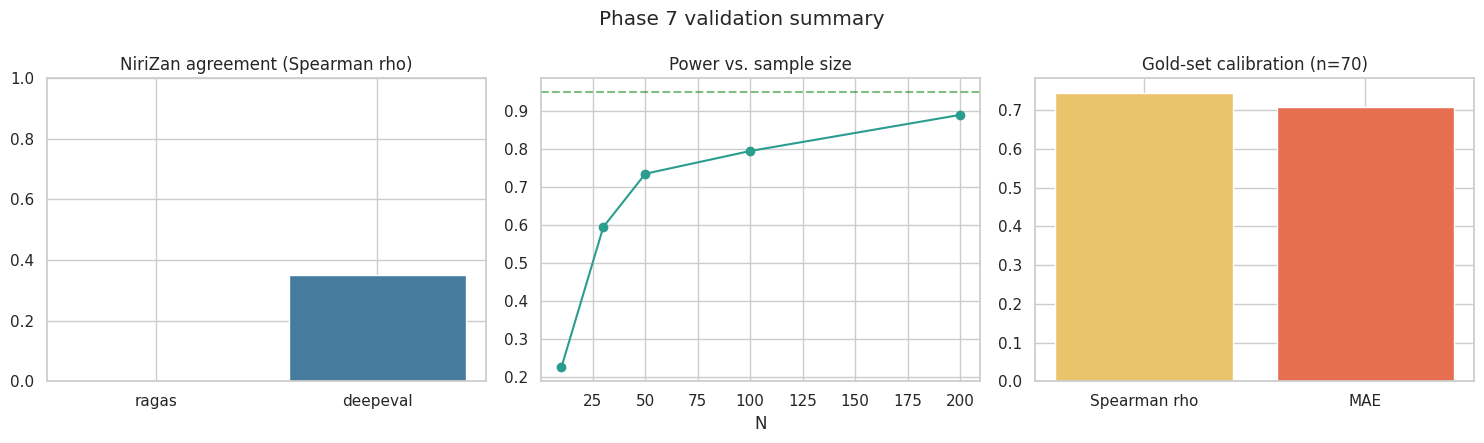

In [24]:
# ============================================================================
# Code Cell 24 — Visualize the consolidated results dashboard
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

if summary.tool_agreement:
    tools = [t.tool for t in summary.tool_agreement]
    rhos = [t.spearman_rho for t in summary.tool_agreement]
    axes[0].bar(tools, rhos, color="#457b9d")
    axes[0].set_ylim(0, 1)
else:
    axes[0].text(0.5, 0.5, "no external\ntool scores", ha="center", va="center")
axes[0].set_title("NiriZan agreement (Spearman rho)")

if summary.sample_size_sweep:
    ns = [p.n for p in summary.sample_size_sweep]
    powers = [p.power for p in summary.sample_size_sweep]
    axes[1].plot(ns, powers, "o-", color="#2a9d8f")
    axes[1].axhline(0.95, color="green", linestyle="--", alpha=0.5)
    axes[1].set_xlabel("N")
axes[1].set_title("Power vs. sample size")

axes[2].bar(
    ["Spearman rho", "MAE"],
    [summary.gold_set_spearman_rho, summary.gold_set_mae],
    color=["#e9c46a", "#e76f51"],
)
axes[2].set_title(f"Gold-set calibration (n={summary.gold_set_size})")

fig.suptitle("Phase 7 validation summary")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "results_dashboard.pdf")
plt.show()


### Results table for the paper

| Result | Value |
|---|---|
| Dataset sources | see `dataset_sources` above (`real` or `fallback` per dataset) |
| NiriZan vs. RAGAS agreement (Spearman rho) | see `tool_agreement`, populated only if an LLM key was set |
| NiriZan vs. DeepEval agreement (Spearman rho) | see `tool_agreement`, populated only if an LLM key was set |
| False-alarm rate / power across N in {10,30,50,100,200} | see `sample_size_sweep` |
| Gold-set Spearman rho (95% CI, N=`gold_set_size`) | see `gold_set_spearman_rho` / `_ci` |
| Gold-set MAE (95% CI) | see `gold_set_mae` / `_ci` |
| 2x2 factorial: control / system / judge verdicts | see `factorial_cases`, `matched_expectation` |
| Compound-drift verdict (no matching enum state) | see `factorial_cases`, case `compound_drift` |
| Recommended N for 95% power, by effect size | see `recommended_n_by_effect_size` |

Every figure referenced above was saved as a vector PDF to `paper_figures/`
during its own section, at the point it was computed, not regenerated here.


## 15. Production Extraction Map

This notebook produces no new `src/nirizan/` files. Everything below is evaluation-of-the-evaluation-logic, not production evaluation logic, so the extraction target is `benchmarks/` (sibling to `experiments/`), not the layered package, if this harness is worth running on a schedule rather than once for the paper.

| Notebook Component | Target | Status |
|---|---|---|
| Sections 2-3 (dataset acquisition + real trace building) | `benchmarks/datasets/` | New, if recurring benchmark runs are wanted |
| Section 5's cache (`nirizan_eval_cache.sqlite` schema) | `benchmarks/cache.py` | New, generalizes the "score once, resample many" pattern beyond this notebook |
| Section 6 (agreement analysis) | `benchmarks/external_comparison.py` | New |
| Sections 7 and 10 (sample-size sweep, power curve) | `benchmarks/power_analysis.py` | New, could subsume earlier sample-size estimates |
| Section 9 (2x2 factorial) | `benchmarks/drift_factorial.py` | New; the `compound_drift` finding should also be documented as a known gap in the attribution module, not just this benchmark |
| `Phase7ValidationSummary` | stays notebook-local | Not part of the core package; re-derive per paper draft rather than promoting to `src/` |

## 16. Notebook Conclusion

This notebook provides a real, executed Tier 2 external comparison (Sections 5-6), real-dataset validation replacing synthetic score arrays for the trace-building and calibration steps (Sections 2-3, 8), a sample-size-sensitivity curve replacing two isolated operating points (Sections 7, 10), and a real model-swap judge-drift case extended to the full 2x2 factorial (Section 9), including an honest, unresolved finding about the `compound_drift` case that the current three-state `AttributionEngine` contract cannot fully represent.

What remains open, stated plainly rather than glossed over: Section 5's comparison only ran if the local Ollama judge was reachable at execution time, Section 11's cost/latency comparison is qualitative for the external tools pending per-call instrumentation, and the `COMPOUND_DRIFT` question raised in Section 9 is a known gap in the attribution engine, not something resolved here.


In [25]:
# ============================================================================
# Code Cell 25 — Report installed evaluation-framework versions
# ============================================================================

import importlib.metadata as md

for package in [
    "ragas",
    "langchain",
    "langchain-core",
    "langchain-community",
    "langchain-google-genai",
]:
    try:
        print(
            f"{package}: "
            f"{md.version(package)}"
        )
    except md.PackageNotFoundError:
        print(
            f"{package}: NOT INSTALLED"
        )

ragas: 0.4.3
langchain: 1.3.13
langchain-core: 1.5.5
langchain-community: 0.3.31
langchain-google-genai: 4.3.4


In [26]:
# ============================================================================
# Code Cell 26 — Verify the LangChain VertexAI polyfill
# ============================================================================

try:
    from langchain_community.chat_models.vertexai import ChatVertexAI
    print("ChatVertexAI import: OK")
except Exception as exc:
    print(
        "ChatVertexAI import FAILED:",
        repr(exc),
    )

ChatVertexAI import: OK
